## Smart Customer Segmentation System

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Feature Engineering

In [3]:

df=pd.read_csv(r"C:\Users\AYESHA\OneDrive\Desktop\Datasets\smartcart_customers.csv")
# Handling Missing Values

df["Income"]=df["Income"].fillna(df["Income"].median())
# Feature Engineering

df["age"]=2026-df["Year_Birth"]
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)
refrence_dt=df["Dt_Customer"].max()
df["Customer_tenure"]=(refrence_dt-df["Dt_Customer"]).dt.days

# Spending
df["Total_spent"]=df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]
# Children
df["Total_Kids"]=df["Teenhome"]+df["Kidhome"]
# Education
df["Education"]=df["Education"].replace(
    {
        "Basic":"UnderGraduate",
        "2n Cycle":"UnderGraduate",
        "Graduation":"Graduate",
        "Master":"PostGraduate",
        "PhD":"PostGraduate"
    }
)
df["Living_with"]=df["Marital_Status"].replace(
    {
        "Married":"Partner",
        "Together":"Partner",
        "Single":"Alone",
        "Widow":"Alone",
        "Divorced":"Alone",
        "YOLO":"Alone",
        "Absurd":"Alone"
    }
)
# Drop Columns
cols=["ID","Marital_Status","Year_Birth","MntWines","MntFruits","MntFishProducts","MntSweetProducts","MntMeatProducts","MntGoldProds","Dt_Customer","Kidhome","Teenhome"]
df_cleaned=df.drop(columns=cols)
df_cleaned.shape


(2240, 15)

In [4]:
# Handling Outliers
col=["Income","Recency","Response","age","Total_spent","Total_Kids"]
# sns.pairplot(df_cleaned[col])
print("Data size with outliers:",len(df_cleaned))
df_cleaned=df_cleaned[(df_cleaned["age"]<90)]
df_cleaned=df_cleaned[(df_cleaned["Income"]<600_000)]
print("Data size without outliers:",len(df_cleaned))

Data size with outliers: 2240
Data size without outliers: 2236


<Axes: >

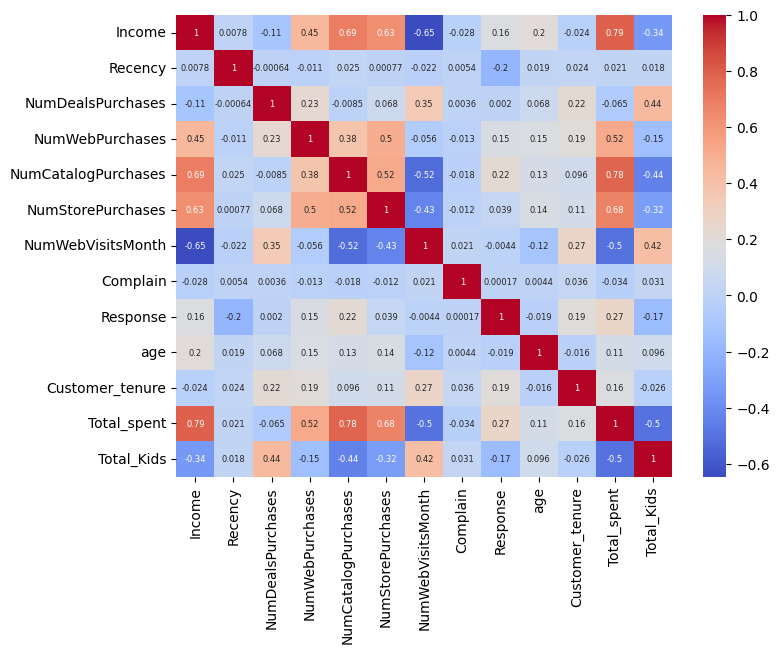

In [5]:
# Co-relation
corr=df_cleaned.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
)


 Encoding&Scaling

In [6]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
ohe=OneHotEncoder()
cat_cols=["Education","Living_with"]
enc_cols=ohe.fit_transform(df_cleaned[cat_cols])
enc_df=pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=df_cleaned.index)
df_encoded=pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)
scaler=StandardScaler()
X=df_encoded
X_Scaled=scaler.fit_transform(X)


Visualization

Text(0.5, 0.92, '3D Projection')

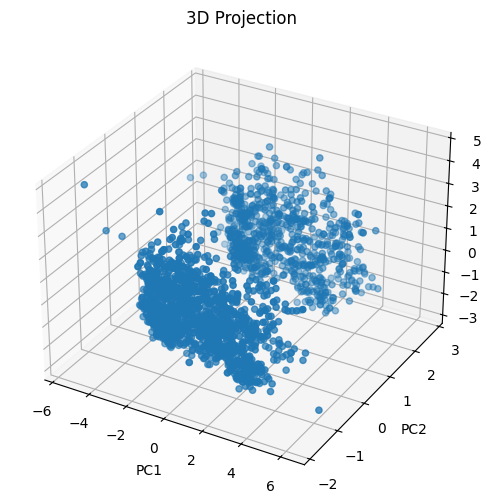

In [7]:
from sklearn.decomposition import PCA
pca=PCA(n_components=3)
X_pca=pca.fit_transform(X_Scaled)
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D Projection")


Elbow & Silhouette

In [8]:
from sklearn.cluster import KMeans
from kneed import KneeLocator
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)
knee=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
print("Optimal K:",knee.elbow)
print(wcss)

Optimal K: 4
[18093.257793324534, 10760.843401758222, 8830.288717243036, 6650.969417658867, 5006.161168001195, 4396.308699108109, 3857.633064427573, 3207.0576242216634, 3025.223255432587, 2651.4429891061486]


Text(0, 0.5, 'SS')

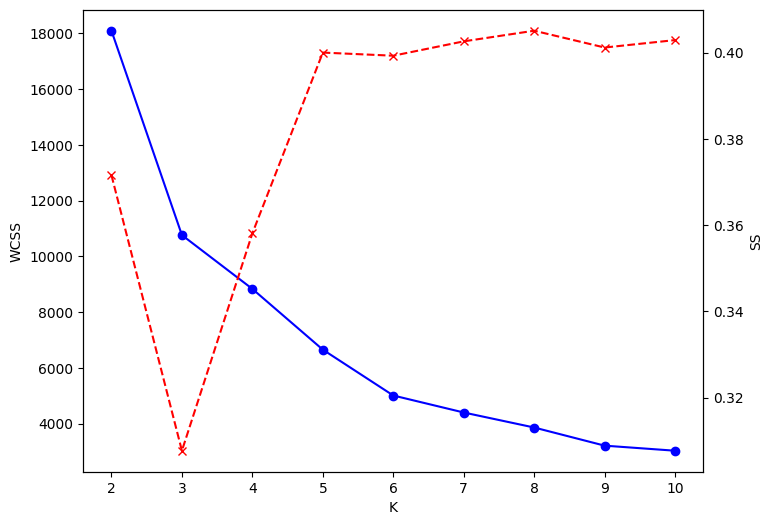

In [9]:
from sklearn.metrics import silhouette_score
scores=[]
for k in range(2,11):
    model=KMeans(n_clusters=k,random_state=42)
    labels=model.fit_predict(X_pca)
    score=silhouette_score(X_pca,labels)
    scores.append(score)

k_range=range(2,11)
fig,ax1=plt.subplots(figsize=(8,6))
ax1.plot(k_range,wcss[:len(k_range)],marker="o",color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")
ax2=ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker="x",color="red",linestyle="--")
ax2.set_ylabel("SS")


KMeans

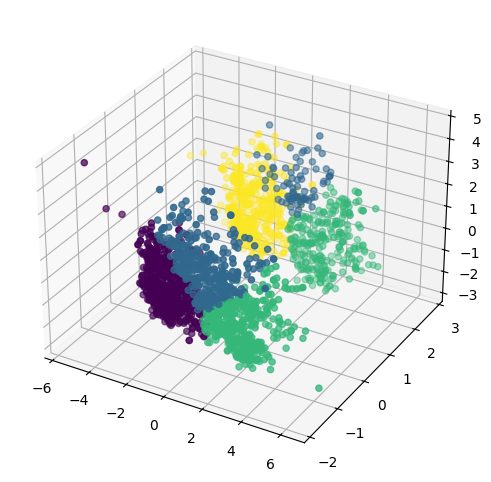

In [10]:
kmeans=KMeans(n_clusters=4,random_state=42)
l=kmeans.fit_predict(X_pca)
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=l)

Algomarative Clustering

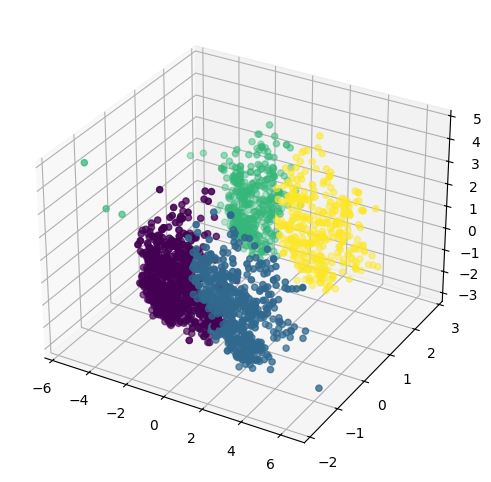

In [11]:
from sklearn.cluster import AgglomerativeClustering
ac=AgglomerativeClustering(n_clusters=4,linkage="ward")
l1=ac.fit_predict(X_pca)
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=l1)



Charcterization of Clusters

<Axes: xlabel='clusters', ylabel='count'>

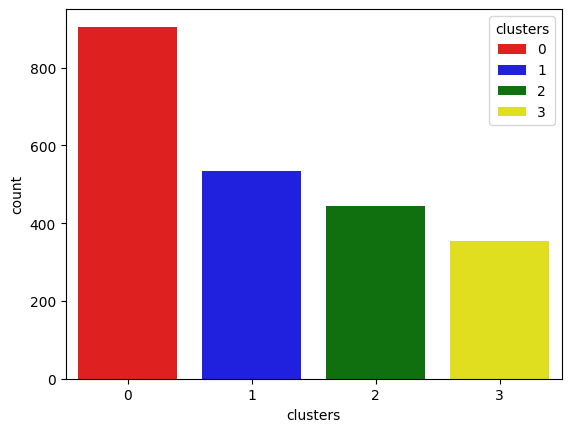

In [12]:

X["clusters"] = l1
pal=["red","blue","green","yellow"]
sns.countplot(x=X["clusters"],palette=pal,hue=X["clusters"])


In [13]:
cluster_summary=X.groupby("clusters").mean()
print(cluster_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
clusters                                                                
0         39680.580110  48.914917           2.594475         3.153591   
1         72808.445693  49.202247           1.958801         5.687266   
2         36960.143018  48.319820           2.594595         2.713964   
3         70722.681303  50.504249           1.855524         5.790368   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
clusters                                                                        
0                    0.969061           4.143646           6.307182  0.011050   
1                    5.498127           8.659176           3.580524  0.005618   
2                    0.837838           3.623874           6.659910  0.011261   
3                    5.014164           8.430595           3.728045  0.005666   

          Response        age  Customer_tenure  Total_spent  Total_Kids  \